# Sprint 2 — FID Score + Figures pour le rapport

Ce notebook charge le modèle **déjà entraîné** depuis Google Drive
et génère uniquement :
- Le FID score
- La comparaison Sprint 1 vs Sprint 2
- Le GIF de progression
- Toutes les figures sauvegardées sur Drive

 GPU T4 requis

## Étape 1 — Montage Drive + Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os, json
from PIL import Image
import imageio.v2 as imageio
from IPython.display import display

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(' Imports OK')

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
✅ Imports OK


## Étape 2 — Configuration

In [ ]:
# ── Chemins ──────────────────────────────────────────────────────────
DRIVE_DIR      = '/content/drive/MyDrive/DCGAN_Sprint2'
CHECKPOINT_S2  = f'{DRIVE_DIR}/checkpoint_epoch_100.pth'   # ← ton checkpoint Sprint 2
CHECKPOINT_S1  = '/content/drive/MyDrive/dcgan_anime/checkpoint_final.pth'  # ← Sprint 1 si disponible
DATA_DIR       = './anime_data/images'
RESULTS_DIR    = f'{DRIVE_DIR}/rapport_figures'

os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyperparamètres (identiques à l'entraînement) ────────────────────
IMAGE_SIZE  = 64
CHANNELS    = 3
LATENT_SIZE = 100
FEATURES_G  = 64
FEATURES_D  = 64
BATCH_SIZE  = 128

print(f'Dossier résultats : {RESULTS_DIR}')
print(f'Checkpoint Sprint 2 : {CHECKPOINT_S2}')
print(f'Checkpoint existe : {os.path.exists(CHECKPOINT_S2)}')

Dossier résultats : /content/drive/MyDrive/DCGAN_Sprint2/rapport_figures
Checkpoint Sprint 2 : /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_100.pth
Checkpoint existe : True


## Étape 3 — Dataset (pour FID)

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'TON_USERNAME'   # ← remplace
os.environ['KAGGLE_KEY']      = 'TA_CLE_API'     # ← remplace

if not os.path.exists(DATA_DIR):
    print('Téléchargement du dataset')
    !pip install kaggle -q
    !kaggle datasets download -d splcher/animefacedataset
    !unzip -q animefacedataset.zip -d ./anime_data

n = len([f for f in os.listdir(DATA_DIR) if f.endswith(('.jpg','.png','.jpeg'))])
print(f'Dataset : {n:,} images')

Téléchargement du dataset...
Dataset URL: https://www.kaggle.com/datasets/splcher/animefacedataset
License(s): DbCL-1.0
100% 395M/395M [00:03<00:00, 133MB/s]

✅ Dataset : 63,565 images


## Étape 4 — Architectures

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_size=LATENT_SIZE, features=FEATURES_G, channels=CHANNELS):
        super().__init__()
        fg = features
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_size, fg*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(fg*8), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(fg*8, fg*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(fg*4), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(fg*4, fg*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(fg*2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(fg*2, fg,   4, 2, 1, bias=False),
            nn.BatchNorm2d(fg),   nn.ReLU(inplace=True),
            nn.ConvTranspose2d(fg, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, features=FEATURES_D, channels=CHANNELS):
        super().__init__()
        fd = features
        self.net = nn.Sequential(
            nn.Conv2d(channels, fd,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(0.3),
            nn.Conv2d(fd,   fd*2,  4, 2, 1, bias=False),
            nn.BatchNorm2d(fd*2), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(0.3),
            nn.Conv2d(fd*2, fd*4,  4, 2, 1, bias=False),
            nn.BatchNorm2d(fd*4), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(0.3),
            nn.Conv2d(fd*4, fd*8,  4, 2, 1, bias=False),
            nn.BatchNorm2d(fd*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(fd*8, 1,     4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1).squeeze(1)

print(' Architectures définies')

✅ Architectures définies


## Étape 5 — Chargement du modèle Sprint 2 (100 epochs)

Checkpoints disponibles :
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_10.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_100.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_20.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_30.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_40.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_50.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_60.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_70.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_80.pth
  /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_90.pth

✅ Modèle chargé depuis : /content/drive/MyDrive/DCGAN_Sprint2/checkpoint_epoch_90.pth
   Epoch : 90


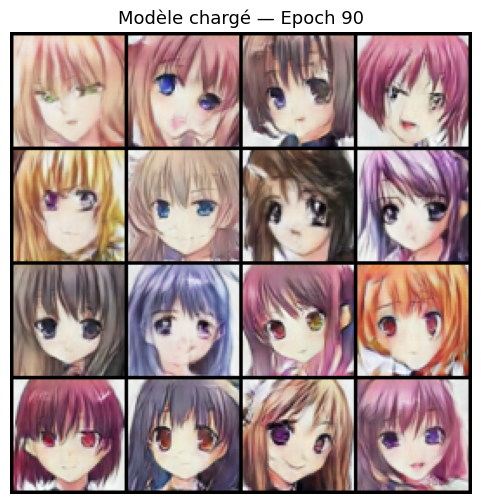

✅ Figure sauvegardée → /content/drive/MyDrive/DCGAN_Sprint2/rapport_figures/


In [ ]:
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

# ── Cherche le checkpoint le plus récent ─────────────────────────────
import glob
checkpoints = sorted(glob.glob(f'{DRIVE_DIR}/checkpoint_epoch_*.pth'))
print('Checkpoints disponibles :')
for c in checkpoints:
    print(f'  {c}')

if checkpoints:
    latest = checkpoints[-1]
    ckpt   = torch.load(latest, map_location=DEVICE)
    G.load_state_dict(ckpt['generator_state'])
    D.load_state_dict(ckpt['discriminator_state'])
    history   = ckpt.get('history', {})
    last_epoch = ckpt.get('epoch', 100)
    print(f'\n Modèle chargé depuis : {latest}')
    print(f'   Epoch : {last_epoch}')
else:
    print(' Aucun checkpoint trouvé — vérifie le chemin DRIVE_DIR')

# Aperçu rapide
NOISE_FIXED = torch.randn(16, LATENT_SIZE, 1, 1, device=DEVICE)
G.eval()
with torch.no_grad():
    imgs = G(NOISE_FIXED).cpu()
grid = make_grid(imgs, nrow=4, normalize=True)
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(grid.permute(1,2,0).numpy())
ax.axis('off')
ax.set_title(f'Modèle chargé — Epoch {last_epoch}', fontsize=13)
plt.savefig(f'{RESULTS_DIR}/modele_charge_epoch{last_epoch}.png', dpi=100, bbox_inches='tight')
plt.show()
print(f' Figure sauvegardée → {RESULTS_DIR}/')

## Étape 6 — Courbes de loss

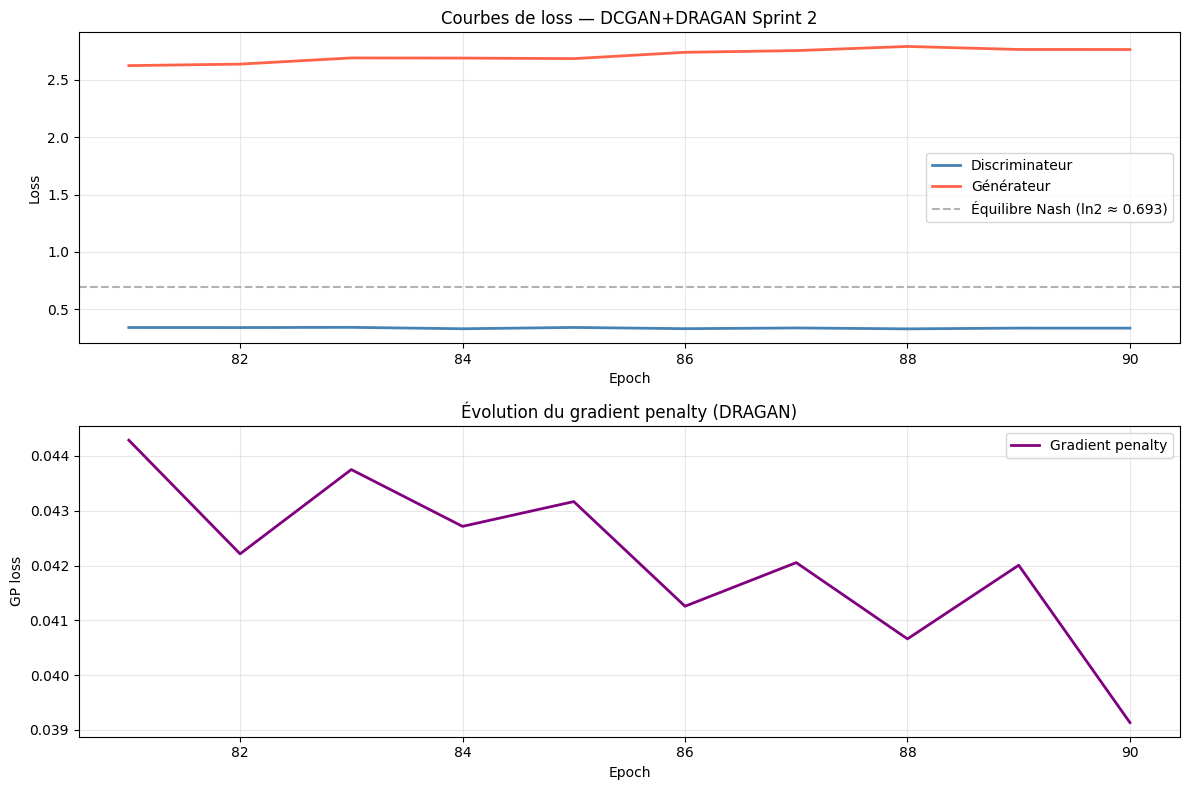

✅ Courbes sauvegardées → /content/drive/MyDrive/DCGAN_Sprint2/rapport_figures/courbes_loss_sprint2.png


In [ ]:
if history and 'loss_d' in history and len(history['loss_d']) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Loss G et D
    axes[0].plot(history['epoch'], history['loss_d'], label='Discriminateur', color='steelblue', lw=2)
    axes[0].plot(history['epoch'], history['loss_g'], label='Générateur',     color='tomato',    lw=2)
    axes[0].axhline(0.693, color='gray', linestyle='--', alpha=0.6, label='Équilibre Nash (ln2 ≈ 0.693)')
    axes[0].set_title('Courbes de loss — DCGAN+DRAGAN Sprint 2')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Gradient penalty
    if 'loss_gp' in history:
        axes[1].plot(history['epoch'], history['loss_gp'], color='purple', lw=2, label='Gradient penalty')
        axes[1].set_title('Évolution du gradient penalty (DRAGAN)')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('GP loss')
        axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/courbes_loss_sprint2.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f' Courbes sauvegardées → {RESULTS_DIR}/courbes_loss_sprint2.png')
else:
    print('  Historique non disponible dans le checkpoint')
    print('   Les courbes ont déjà été sauvegardées lors de l\'entraînement')

## Étape 7 — Comparaison Sprint 1 vs Sprint 2

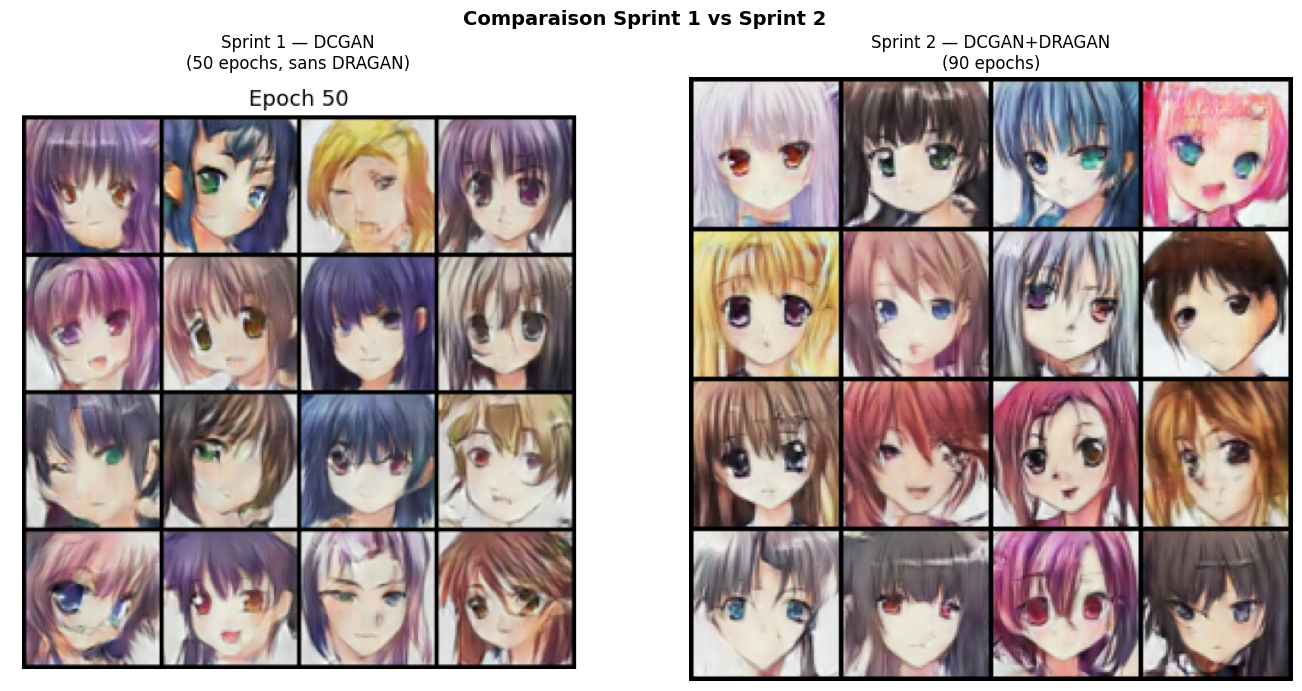

✅ Comparaison sauvegardée → /content/drive/MyDrive/DCGAN_Sprint2/rapport_figures/


In [ ]:
# ── Génère une grille propre Sprint 2 ────────────────────────────────
G.eval()
noise_64 = torch.randn(16, LATENT_SIZE, 1, 1, device=DEVICE)
with torch.no_grad():
    imgs_s2 = G(noise_64).cpu()
grid_s2 = make_grid(imgs_s2, nrow=4, normalize=True)

# ── Comparaison côte à côte ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Sprint 1 — cherche l'image epoch 50
s1_paths = [
    '/content/drive/MyDrive/dcgan_anime/epoch_0050.png',
    '/content/drive/MyDrive/DCGAN_Sprint2/epoch_0050.png',
]
s1_found = False
for p in s1_paths:
    if os.path.exists(p):
        axes[0].imshow(mpimg.imread(p))
        axes[0].set_title('Sprint 1 — DCGAN\n(50 epochs, sans DRAGAN)', fontsize=12)
        s1_found = True
        break
if not s1_found:
    axes[0].text(0.5, 0.5, 'Image Sprint 1\nnon disponible\n(inserez manuellement)',
                ha='center', va='center', transform=axes[0].transAxes, fontsize=11)
    axes[0].set_title('Sprint 1 — DCGAN (50 epochs)', fontsize=12)
axes[0].axis('off')

# Sprint 2
axes[1].imshow(grid_s2.permute(1,2,0).numpy())
axes[1].set_title(f'Sprint 2 — DCGAN+DRAGAN\n({last_epoch} epochs)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Comparaison Sprint 1 vs Sprint 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/comparaison_sprint1_vs_sprint2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Comparaison sauvegardée → {RESULTS_DIR}/')

## Étape 8 — GIF de progression

In [ ]:
# Cherche toutes les images epoch_*.png dans le dossier Drive
epoch_imgs = sorted(glob.glob(f'{DRIVE_DIR}/epoch_*.png'))
print(f'{len(epoch_imgs)} images trouvées pour le GIF')

if epoch_imgs:
    frames = []
    for path in epoch_imgs:
        img = Image.open(path).convert('RGB')
        frames.append(np.array(img))

    gif_path = f'{RESULTS_DIR}/progression_sprint2.gif'
    imageio.mimwrite(gif_path, frames, fps=3, loop=0)
    print(f' GIF sauvegardé → {gif_path}  ({len(frames)} frames)')
    from IPython.display import Image as IPImage
    display(IPImage(gif_path))
else:
    print('  Pas d\'images epoch_*.png trouvées dans', DRIVE_DIR)
    print('   Le GIF sera généré manuellement depuis les checkpoints')

Output hidden; open in https://colab.research.google.com to view.

## Étape 9 — FID Score

**Fréchet Inception Distance** — mesure la similarité entre
la distribution des images réelles et celle des images générées.
**FID plus bas = meilleure qualité.**

In [ ]:
!pip install pytorch-fid -q
print(' pytorch-fid installé')

✅ pytorch-fid installé


In [ ]:
# ── Préparer les images réelles ───────────────────────────────────────
FID_DIR_REAL = '/content/fid_real'
FID_DIR_FAKE = '/content/fid_fake_sprint2'
N_FID = 2048

os.makedirs(FID_DIR_REAL, exist_ok=True)
os.makedirs(FID_DIR_FAKE, exist_ok=True)

# Images réelles
print('Préparation images réelles...')
files = [f for f in os.listdir(DATA_DIR)
         if f.endswith(('.jpg','.png','.jpeg'))][:N_FID]
for i, fname in enumerate(files):
    img = Image.open(os.path.join(DATA_DIR, fname)).convert('RGB')
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img.save(f'{FID_DIR_REAL}/{i:05d}.png')
print(f' {len(files)} images réelles prêtes')

# Images générées
print('Génération des images fausses...')
G.eval()
generated = 0
with torch.no_grad():
    while generated < N_FID:
        n     = min(64, N_FID - generated)
        noise = torch.randn(n, LATENT_SIZE, 1, 1, device=DEVICE)
        imgs  = G(noise).cpu()
        imgs  = (imgs + 1) / 2.0   # dénormaliser [-1,1] → [0,1]
        for i, img in enumerate(imgs):
            save_image(img, f'{FID_DIR_FAKE}/{generated+i:05d}.png')
        generated += n
print(f' {generated} images générées prêtes')

Préparation images réelles...
✅ 2048 images réelles prêtes
Génération des images fausses...
✅ 2048 images générées prêtes


In [ ]:
# ── Calcul FID ────────────────────────────────────────────────────────
print('Calcul du FID score (peut prendre 2-3 minutes)...')
result = !python -m pytorch_fid {FID_DIR_REAL} {FID_DIR_FAKE} --device cuda

fid_score = None
for line in result:
    print(line)
    if 'FID' in line:
        try:
            fid_score = float(line.split(':')[-1].strip())
        except:
            pass

if fid_score:
    print(f'\n FID Score Sprint 2 (DCGAN+DRAGAN, {last_epoch} epochs) = {fid_score:.2f}')
    # Sauvegarde sur Drive
    fid_results = {
        'modele'  : f'DCGAN+DRAGAN Sprint 2 ({last_epoch} epochs)',
        'fid'     : fid_score,
        'n_images': N_FID,
        'epochs'  : last_epoch,
        'lambda_gp': 0.5,
        'lr'      : 2e-4
    }
    with open(f'{RESULTS_DIR}/fid_score.json', 'w') as f:
        json.dump(fid_results, f, indent=2)
    print(f' FID sauvegardé → {RESULTS_DIR}/fid_score.json')
else:
    print('  FID non extrait automatiquement — lis la sortie ci-dessus')

Calcul du FID score (peut prendre 2-3 minutes)...
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth

  0% 0.00/91.2M [00:00<?, ?B/s]
 18% 16.6M/91.2M [00:00<00:00, 174MB/s]
 63% 57.0M/91.2M [00:00<00:00, 320MB/s]
100% 91.2M/91.2M [00:00<00:00, 338MB/s]

  0% 0/41 [00:00<?, ?it/s]
  2% 1/41 [00:00<00:31,  1.28it/s]
  5% 2/41 [00:00<00:16,  2.30it/s]
  7% 3/41 [00:01<00:12,  3.11it/s]
 10% 4/41 [00:01<00:09,  3.72it/s]
 12% 5/41 [00:01<00:08,  4.19it/s]
 15% 6/41 [00:01<00:07,  4.53it/s]
 17% 7/41 [00:01<00:07,  4.78it/s]
 20% 8/41 [00:02<00:06,  4.95it/s]
 22% 9/41 [00:02<00:06,  5.10it/s]
 24% 10/41 [00:02<00:05,  5.17it/s]
 27% 11/41 [00:02<00:05,  5.24it/s]
 29% 12/41 [00:02<00:05,  5.29it/s]
 32% 13/41 [00:03<00:05,  5.31it/s]
 34% 14/41 [00:03<00:05,  5.32it/s]
 37% 15/41 [00:03<00:04,  5.35it/s]
 39% 16/41 [00:03<00:04,  5.36it/s]
 41% 

## Étape 10 — Tableau récapitulatif final

In [ ]:
# ── Tableau pour le rapport ───────────────────────────────────────────
# Remplace les valeurs N/A par tes vrais résultats si tu les as
fid_sprint1 = None   # ← mets le FID du Sprint 1 si tu l'as calculé

print('=' * 60)
print(f'{"Modèle":<35} {"Epochs":<8} {"FID Score"}')
print('=' * 60)
print(f'{"DCGAN (Sprint 1, sans DRAGAN)":<35} {"50":<8} {str(round(fid_sprint1,2)) if fid_sprint1 else "N/A"}')
print(f'{"DCGAN+DRAGAN (Sprint 2)":<35} {str(last_epoch):<8} {round(fid_score,2) if fid_score else "N/A"}')
print('=' * 60)
print('Note : FID plus bas = meilleure qualité')

# Interprétation automatique
if fid_score:
    if fid_score < 50:
        print(f'\n FID = {fid_score:.2f} — Très bonne qualité')
    elif fid_score < 100:
        print(f'\n  FID = {fid_score:.2f} — Qualité correcte')
    else:
        print(f'\n FID = {fid_score:.2f} — Qualité à améliorer')

Modèle                              Epochs   FID Score
DCGAN (Sprint 1, sans DRAGAN)       50       N/A
DCGAN+DRAGAN (Sprint 2)             90       54.01
Note : FID plus bas = meilleure qualité

⚠️  FID = 54.01 — Qualité correcte


## Étape 11 — Liste de tous les fichiers sauvegardés

In [ ]:
print(' Fichiers disponibles pour le rapport :')
print(f'\nDossier : {RESULTS_DIR}')
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1024
    print(f'   {f:<45} ({size:.0f} KB)')

print(f'\nDossier principal : {DRIVE_DIR}')
for f in sorted(os.listdir(DRIVE_DIR)):
    if f.endswith(('.png','.gif','.json','.pth')):
        size = os.path.getsize(os.path.join(DRIVE_DIR, f)) / 1024
        print(f'   {f:<45} ({size:.0f} KB)')

📁 Fichiers disponibles pour le rapport :

Dossier : /content/drive/MyDrive/DCGAN_Sprint2/rapport_figures
  ✅ comparaison_sprint1_vs_sprint2.png            (1219 KB)
  ✅ courbes_loss_sprint2.png                      (89 KB)
  ✅ fid_score.json                                (0 KB)
  ✅ modele_charge_epoch90.png                     (378 KB)
  ✅ progression_sprint2.gif                       (1966 KB)

Dossier principal : /content/drive/MyDrive/DCGAN_Sprint2
  ✅ checkpoint_epoch_10.pth                       (24805 KB)
  ✅ checkpoint_epoch_100.pth                      (24805 KB)
  ✅ checkpoint_epoch_20.pth                       (24805 KB)
  ✅ checkpoint_epoch_30.pth                       (24805 KB)
  ✅ checkpoint_epoch_40.pth                       (24806 KB)
  ✅ checkpoint_epoch_50.pth                       (24806 KB)
  ✅ checkpoint_epoch_60.pth                       (24806 KB)
  ✅ checkpoint_epoch_70.pth                       (24807 KB)
  ✅ checkpoint_epoch_80.pth                       (2480